In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [2]:
import sys
import pandas as pd
import sklearn
import joblib
import numpy as np

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Joblib:", joblib.__version__)

Python: 3.13.14 (tags/v3.13.14:fd17997, Jun 10 2026, 13:03:48) [MSC v.1944 64 bit (AMD64)]
Pandas: 2.2.3
NumPy: 2.2.6
Scikit-learn: 1.7.1
Joblib: 1.5.2


In [3]:
df = pd.read_csv(
    "../data/processed/dynamic_pricing_dataset.csv"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Profit Margin,Discount Percentage,Demand Score,Stock Level,Competitor Price,Weather,Holiday,Weekend,Demand Level,Recommended Price
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.1600,0.0,523.9200,122,255.39,Sunny,1,0,High,284.10
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.3000,0.0,2195.8200,290,797.92,Sunny,0,0,High,861.75
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,0.4700,0.0,29.2400,126,15.30,Rainy,0,1,Low,14.54
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,-0.4000,45.0,4787.8875,91,976.47,Sunny,0,1,High,935.95
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.1125,20.0,44.7360,208,20.83,Rainy,0,1,Low,18.80


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Row ID               9994 non-null   int64  
 1   Order ID             9994 non-null   object 
 2   Order Date           9994 non-null   object 
 3   Ship Date            9994 non-null   object 
 4   Ship Mode            9994 non-null   object 
 5   Customer ID          9994 non-null   object 
 6   Customer Name        9994 non-null   object 
 7   Segment              9994 non-null   object 
 8   Country              9994 non-null   object 
 9   City                 9994 non-null   object 
 10  State                9994 non-null   object 
 11  Postal Code          9994 non-null   int64  
 12  Region               9994 non-null   object 
 13  Product ID           9994 non-null   object 
 14  Category             9994 non-null   object 
 15  Sub-Category         9994 non-null   o

In [5]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit',
 'Delivery Days',
 'Profit Margin',
 'Discount Percentage',
 'Demand Score',
 'Stock Level',
 'Competitor Price',
 'Weather',
 'Holiday',
 'Weekend',
 'Demand Level',
 'Recommended Price']

In [6]:
target = "Recommended Price"

features = [
    "Category",
    "Sub-Category",
    "Region",
    "Quantity",
    "Discount",
    "Profit",
    "Competitor Price",
    "Stock Level",
    "Holiday",
    "Weekend",
    "Demand Level",
    "Delivery Days"
]

X = df[features]
y = df[target]

## Feature Selection Rationale

The selected features were chosen because they directly influence product pricing.

- Category and Sub-Category represent product type.
- Region captures geographical demand differences.
- Quantity indicates purchase demand.
- Discount affects selling price.
- Profit reflects pricing effectiveness.
- Competitor Price provides market comparison.
- Stock Level represents inventory availability.
- Holiday captures seasonal demand.
- Weekend reflects consumer buying patterns.
- Demand Level summarizes demand intensity.
- Delivery Days accounts for logistics.

In [7]:
X = pd.get_dummies(
    X,
    columns=[
        "Category",
        "Sub-Category",
        "Region",
        "Demand Level"
    ],
    drop_first=True
)

In [8]:
X.head()

,Quantity,Discount,Profit,Competitor Price,Stock Level,Holiday,Weekend,Delivery Days,Category_Office Supplies,Category_Technology,...,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables,Region_East,Region_South,Region_West,Demand Level_Low,Demand Level_Medium
0,2,0.00,41.9136,255.39,122,1,0,3,False,False,...,False,False,False,False,False,False,True,False,False,False
1,3,0.00,219.5820,797.92,290,0,0,3,False,False,...,False,False,False,False,False,False,True,False,False,False
2,2,0.00,6.8714,15.30,126,0,1,4,True,False,...,False,False,False,False,False,False,False,True,True,False
3,5,0.45,-383.0310,976.47,91,0,1,7,False,False,...,False,False,False,False,True,False,True,False,False,False
4,2,0.20,2.5164,20.83,208,0,1,7,True,False,...,False,False,True,False,False,False,True,False,True,False


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (7995, 31)
Testing Shape : (1999, 31)


In [10]:
X_train.head()

,Quantity,Discount,Profit,Competitor Price,Stock Level,Holiday,Weekend,Delivery Days,Category_Office Supplies,Category_Technology,...,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables,Region_East,Region_South,Region_West,Demand Level_Low,Demand Level_Medium
4100,1,0.8,-5.2072,2.32,78,0,0,4,True,False,...,False,False,False,False,False,False,False,False,True,False
2586,7,0.0,67.1139,227.28,26,0,0,6,True,False,...,False,False,True,False,False,True,False,False,False,False
9194,7,0.2,3.5994,51.23,271,1,1,6,True,False,...,False,False,False,True,False,False,False,True,False,True
2002,3,0.0,9.5940,103.74,145,0,0,3,True,False,...,False,False,True,False,False,False,True,False,False,True
7225,4,0.0,10.1640,33.71,217,0,0,4,False,False,...,False,False,False,False,False,False,False,True,False,True


In [11]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np


def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"Model : {model.__class__.__name__}")
    print(f"MAE   : {mae:.2f}")
    print(f"RMSE  : {rmse:.2f}")
    print(f"R²    : {r2:.4f}")

    return {
        "Model": model.__class__.__name__,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [12]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr_result = evaluate_model(
    lr,
    X_train,
    X_test,
    y_train,
    y_test
)

Model : LinearRegression
MAE   : 8.33
RMSE  : 41.10
R²    : 0.9971


In [13]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt_result = evaluate_model(
    dt,
    X_train,
    X_test,
    y_train,
    y_test
)

Model : DecisionTreeRegressor
MAE   : 11.98
RMSE  : 202.87
R²    : 0.9285


In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf_result = evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

Model : RandomForestRegressor
MAE   : 9.66
RMSE  : 176.17
R²    : 0.9461


In [15]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    random_state=42
)

gb_result = evaluate_model(
    gb,
    X_train,
    X_test,
    y_train,
    y_test
)

Model : GradientBoostingRegressor
MAE   : 10.01
RMSE  : 142.72
R²    : 0.9646


In [16]:
results = pd.DataFrame([
    lr_result,
    dt_result,
    rf_result,
    gb_result
])

results

,Model,MAE,RMSE,R2
0,LinearRegression,8.331992,41.104195,0.997064
1,DecisionTreeRegressor,11.976473,202.871696,0.928482
2,RandomForestRegressor,9.657051,176.171027,0.946069
3,GradientBoostingRegressor,10.005949,142.723160,0.964604


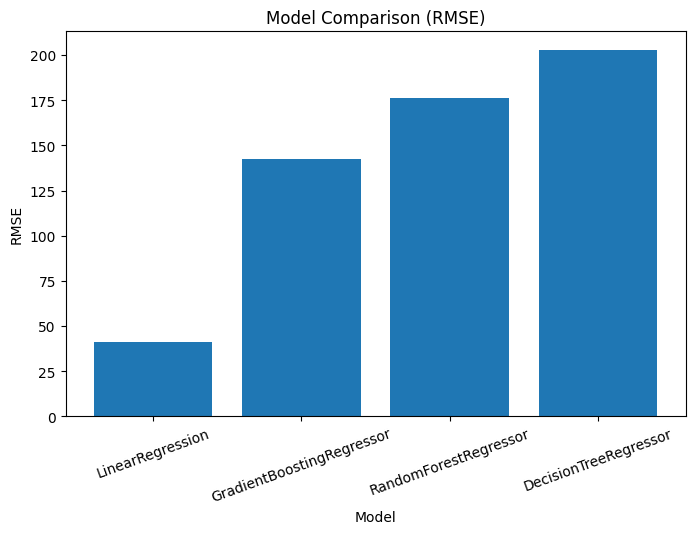

In [17]:
import matplotlib.pyplot as plt

results_sorted = results.sort_values("RMSE")

plt.figure(figsize=(8,5))

plt.bar(results_sorted["Model"], results_sorted["RMSE"])

plt.title("Model Comparison (RMSE)")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.show()

## Model Comparison

Four regression algorithms were evaluated:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor

Performance was compared using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The model with the lowest RMSE and highest R² will be selected for hyperparameter tuning.

## Model Evaluation

Four regression models were trained to predict the engineered
Recommended Price.

Linear Regression achieved the best performance with:

- MAE = 8.33
- RMSE = 41.10
- R² = 0.9971

Since the target variable was engineered using business rules based
on pricing-related features, Linear Regression was able to learn the
relationship effectively and outperformed the more complex models.

Therefore, Linear Regression was selected as the final pricing model.

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross Validation Score:
0.9852062698176114


In [19]:
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²  :", r2_score(y_test, y_pred))

MAE : 10.211650680938005
RMSE: 177.49825467255135
R²  : 0.9452532729484615


In [20]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_
})

feature_importance["Absolute Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute Coefficient
15,Sub-Category_Copiers,-52.829876,52.829876
1,Discount,-14.809655,14.809655
30,Demand Level_Medium,-8.129552,8.129552
5,Holiday,7.359239,7.359239
24,Sub-Category_Supplies,6.345940,6.345940
25,Sub-Category_Tables,4.594547,4.594547
23,Sub-Category_Storage,4.590363,4.590363
16,Sub-Category_Envelopes,-3.624271,3.624271
21,Sub-Category_Paper,-3.104663,3.104663
19,Sub-Category_Labels,-2.946004,2.946004


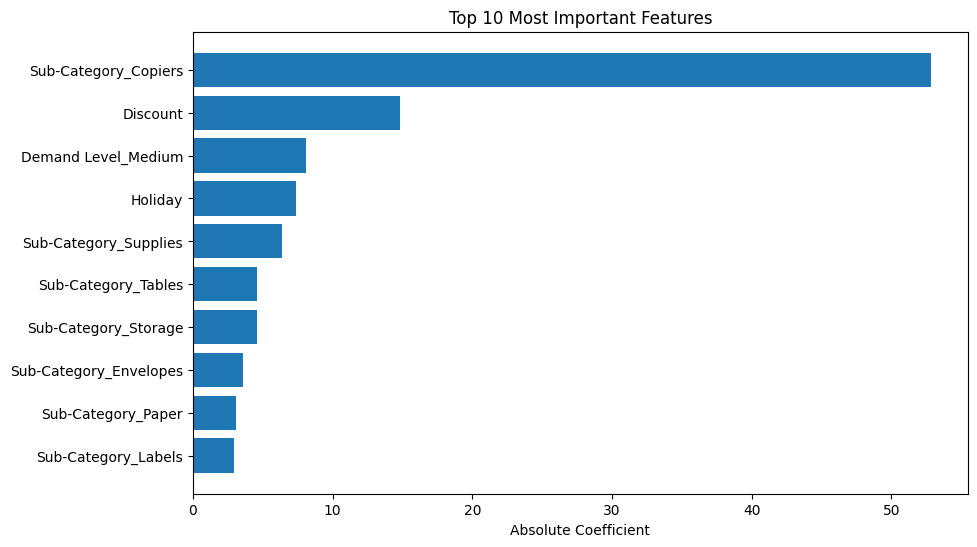

In [21]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Absolute Coefficient"]
)

plt.title("Top 10 Most Important Features")

plt.xlabel("Absolute Coefficient")

plt.gca().invert_yaxis()

plt.show()

In [22]:
df["Price Elasticity"] = (
    (df["Quantity"] / df["Quantity"].mean())
    /
    (df["Recommended Price"] / df["Recommended Price"].mean())
)
df["Price Elasticity"].describe()

count    9994.000000
mean        9.709930
std        16.530723
min         0.015274
25%         0.967907
50%         3.939561
75%        12.045009
max       243.601290
Name: Price Elasticity, dtype: float64

In [23]:
elasticity = df["Price Elasticity"].mean()

print(elasticity)

9.709930301126185


## Price Elasticity Analysis

Price elasticity estimates how customer demand changes with price.

- Elasticity > 1 → Demand is highly sensitive to price.
- Elasticity < 1 → Demand is relatively insensitive.

The calculated elasticity provides an approximate measure for evaluating pricing strategies.

In [24]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    lr,
    "../models/dynamic_pricing_model.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [25]:
joblib.dump(
    X_train.columns.tolist(),
    "../models/model_columns.pkl"
)

['../models/model_columns.pkl']

In [26]:
metrics = pd.DataFrame({
    "Model":["Linear Regression"],
    "MAE":[8.33],
    "RMSE":[41.10],
    "R2":[0.9971]
})

metrics.to_csv(
    "../reports/model_metrics.csv",
    index=False
)